In [1]:
import mitsuba as mi
mi.set_variant("llvm_ad_rgb")

import drjit as dr
print("✅ Dr.Jit syntax available:", hasattr(dr, "syntax"))

✅ Dr.Jit syntax available: True


In [2]:
# ✅ Now load sionna.rt safely
import sionna.rt
print("✅ Fully patched: Sionna RT loaded cleanly with llvm_ad_rgb!")

✅ Fully patched: Sionna RT loaded cleanly with llvm_ad_rgb!


In [3]:
# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

In [4]:
import sionna.rt
import sionna.rt.radio_materials.radio_material
import sionna.rt.radio_materials.itu_material

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver
import numpy as np

In [5]:
from sionna.rt import load_scene

scene = load_scene("/home/fidal/Factory.xml", merge_shapes=False)
scene.frequency = 3.4e9


In [6]:
scene.preview()

In [7]:
from sionna.rt import Camera

# Create camera with only required arguments
my_cam = Camera(
    position=[-40.000,19.748,9.512],
    look_at=[0.0,0.0,0.0]
)

# Set optional attributes manually
my_cam.up = [0, 0, 1]       # Z-axis up
my_cam.fov = 120                   # Field of view
my_cam.resolution = (800, 600)   # Output image resolution

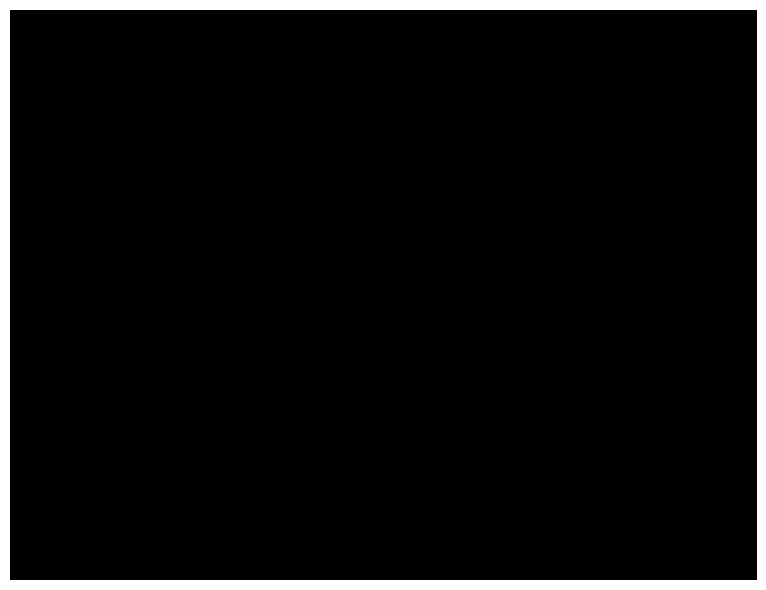

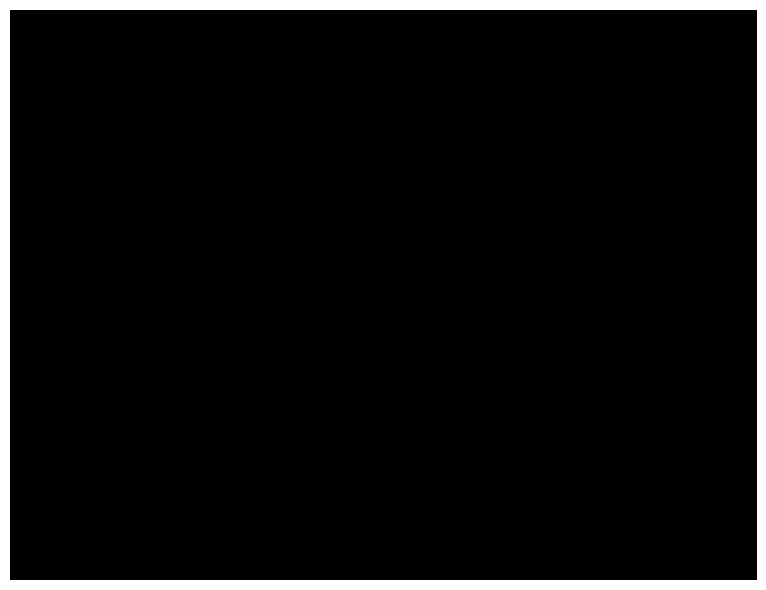

In [8]:
# Render scene with new camera*
image = scene.render(camera=my_cam, num_samples=64, show_devices=False)
from IPython.display import display
display(image)

In [9]:
from sionna.rt import load_scene

scene = load_scene("/home/fidal/Factory.xml", merge_shapes=False)



# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(num_rows=4,
                             num_cols=4,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# Configure antenna array for all receivers
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="cross")

# Create transmitter
tx = Transmitter(name="tx",
                 position=[7.940,1.047,10.000],
                 display_radius=0.5)

# Add transmitter instance to scene
scene.add(tx)

# Create a receiver
rx1 = Receiver(name="rx1",
              position=[0.110,-0.182,-7.015],
              display_radius=0.5)

"""# Create a receiver
rx2 = Receiver(name="rx2",
              position=[0.115,-0.429,-7.000],
              display_radius=0.5)"""

# Add receiver instance to scene
scene.add(rx1)
#scene.add(rx2)

tx.look_at(rx1) # Transmitter points towards receiver
#tx.look_at(rx2)

In [10]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

paths = p_solver(
    scene=scene,
    max_depth=5,
    max_num_paths_per_src=500,
    samples_per_src=50000,   # CRITICAL FOR INDOOR MULTIPATH
    los=True,
    specular_reflection=True,
    diffuse_reflection=True,
    refraction=False,
    synthetic_array=False,
    seed=1
)


⚠️ spectrum_to_matrix_4f: non-polarized Spectrum, using identity Jones fallback: drjit.llvm.ad.Float does not have a 'x' component.


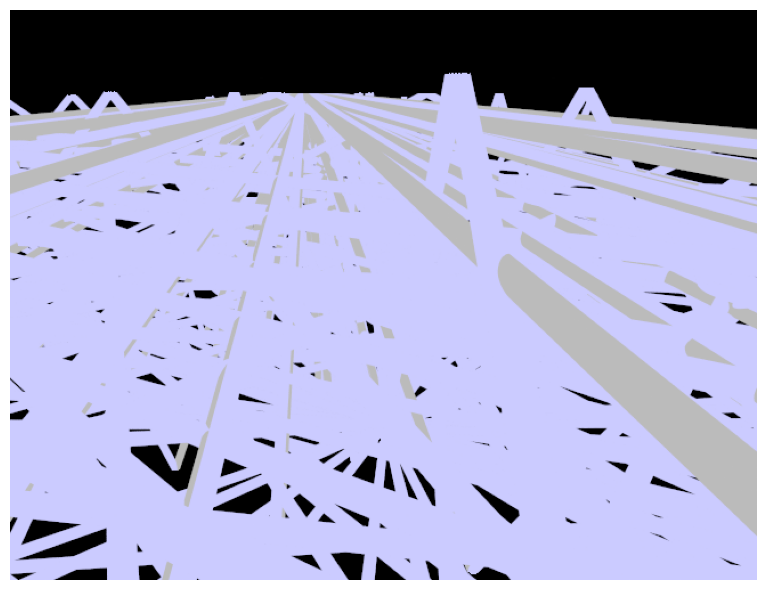

In [11]:
if paths is not None:
    scene.render(camera=my_cam, paths=paths, show_devices=True)
else:
    print("❌ No valid propagation paths found for this scene slice.")
    scene.render(camera=my_cam, show_devices=True)

In [12]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

Shape of a:  (1, 2, 1, 16, 118, 1)
Shape of tau:  (1, 2, 1, 16, 118)


In [13]:
a, tau = paths.cir(normalize_delays=False, out_type="numpy")  # absolute delays
tau_vals = tau.reshape(-1)  # all delays
print("unique delays (ns):", np.unique(np.round(tau_vals/1e-9, 3)))
print("min/max delay (ns):", tau_vals.min()/1e-9, tau_vals.max()/1e-9)

unique delays (ns): [-1.000000e+09  6.261200e+01  6.277600e+01  1.444960e+02  1.445150e+02
  1.445380e+02  1.445670e+02  1.446270e+02  1.446460e+02  1.446700e+02
  1.446980e+02  1.447590e+02  1.447770e+02  1.448010e+02  1.448300e+02
  1.448900e+02  1.449090e+02  1.449320e+02  1.449610e+02  1.497690e+02
  1.497870e+02  1.497920e+02  1.498560e+02  1.498940e+02  1.499110e+02
  1.499160e+02  1.499800e+02  1.500180e+02  1.500360e+02  1.500410e+02
  1.501040e+02  1.501420e+02  1.501600e+02  1.501650e+02  1.502290e+02
  1.919480e+02  1.919890e+02  1.919900e+02  1.921270e+02  2.147140e+02
  2.148270e+02  2.148410e+02  2.148540e+02  2.212380e+02  2.212830e+02
  2.213240e+02  2.213680e+02  2.214680e+02  2.215030e+02  2.215540e+02
  2.464100e+02  2.464340e+02  2.464520e+02  2.464580e+02  2.464760e+02
  2.464820e+02  2.465000e+02  2.465240e+02  2.465480e+02  2.465620e+02
  2.465720e+02  2.465860e+02  2.465960e+02  2.466100e+02  2.466200e+02
  2.466340e+02  2.698390e+02  2.698580e+02  2.699780e+02 

Using RX antenna: 0 TX antenna: 2


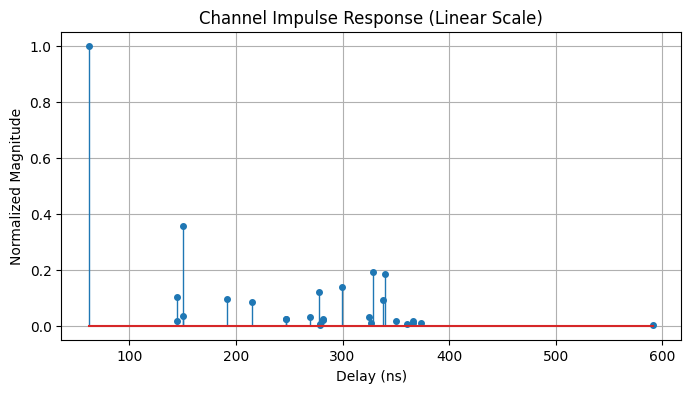

In [14]:
found = False

for rx_ant in range(tau.shape[1]):
    for tx_ant in range(tau.shape[3]):
        valid = tau[0, rx_ant, 0, tx_ant, :] > 0
        if np.sum(valid) > 0:
            found = True
            break
    if found:
        break

if not found:
    print("No valid propagation paths found.")
else:
    print("Using RX antenna:", rx_ant, "TX antenna:", tx_ant)

    tau_sel = tau[0, rx_ant, 0, tx_ant, :]
    a_sel = np.abs(a)[0, rx_ant, 0, tx_ant, :, 0]

    valid = tau_sel > 0
    t = tau_sel[valid] / 1e-9
    a_abs = a_sel[valid]

    a_max = np.max(a_abs)
    a_db = 20*np.log10(a_abs/a_max + 1e-12)

    strong = a_db > -80
    t = t[strong]
    a_db = a_db[strong]

    plt.figure(figsize=(8,4))
markerline, stemlines, baseline = plt.stem(t, a_abs / a_max)
plt.setp(markerline, markersize=4)
plt.setp(stemlines, linewidth=1)
plt.title("Channel Impulse Response (Linear Scale)")
plt.xlabel("Delay (ns)")
plt.ylabel("Normalized Magnitude")
plt.grid(True)
plt.show()

In [15]:
num_subcarriers = 1024
subcarrier_spacing = 30e3

frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

h_freq = paths.cfr(
    frequencies=frequencies,
    normalize=True,
    normalize_delays=True,
    out_type="numpy"
)

print("Shape of h_freq:", h_freq.shape)

Shape of h_freq: (1, 2, 1, 16, 1, 1024)


Using RX antenna: 1 TX antenna: 7


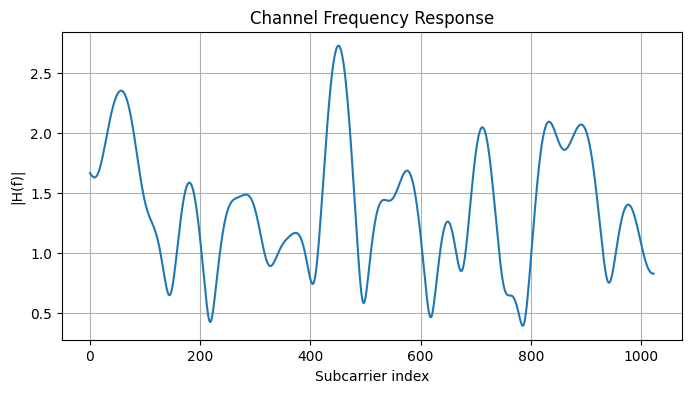

In [16]:
# OFDM system parameters
# Find antenna pair with strongest channel
best_val = -1
best_rx_ant = 0
best_tx_ant = 0

for rx_ant in range(h_freq.shape[1]):
    for tx_ant in range(h_freq.shape[3]):
        val = np.max(np.abs(h_freq[0, rx_ant, 0, tx_ant, 0, :]))
        if val > best_val:
            best_val = val
            best_rx_ant = rx_ant
            best_tx_ant = tx_ant

print("Using RX antenna:", best_rx_ant, "TX antenna:", best_tx_ant)

# Extract frequency response for that antenna pair
h_sel = np.abs(h_freq)[0, best_rx_ant, 0, best_tx_ant, 0, :]

# Plot CFR
plt.figure(figsize=(8,4))
plt.plot(h_sel)
plt.title("Channel Frequency Response")
plt.xlabel("Subcarrier index")
plt.ylabel("|H(f)|")
plt.grid(True)
plt.show()

Shape of taps: (1, 2, 1, 16, 1, 107)
Using RX antenna: 0 TX antenna: 7


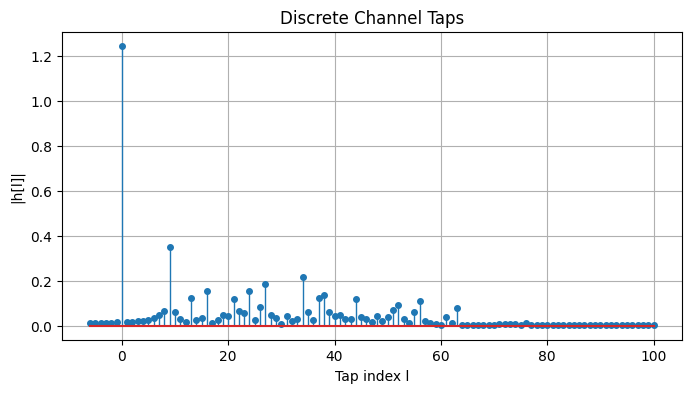

In [17]:
# Compute discrete-time taps
taps = paths.taps(
    bandwidth=100e6,
    l_min=-6,
    l_max=100,
    sampling_frequency=None,
    normalize=True,
    normalize_delays=True,
    out_type="numpy"
)

print("Shape of taps:", taps.shape)

# Find strongest RX/TX antenna pair
best_val = -1
best_rx_ant = 0
best_tx_ant = 0

for rx_ant in range(taps.shape[1]):
    for tx_ant in range(taps.shape[3]):
        val = np.max(np.abs(taps[0, rx_ant, 0, tx_ant, 0, :]))
        if val > best_val:
            best_val = val
            best_rx_ant = rx_ant
            best_tx_ant = tx_ant

print("Using RX antenna:", best_rx_ant, "TX antenna:", best_tx_ant)

# Extract 1D tap vector
tap_idx = np.arange(-6, 101)
tap_abs = np.abs(taps[0, best_rx_ant, 0, best_tx_ant, 0, :]).flatten()

# Optional: keep only meaningful taps
valid = tap_abs > 1e-8
tap_idx = tap_idx[valid]
tap_abs = tap_abs[valid]

# Plot
plt.figure(figsize=(8,4))
markerline, stemlines, baseline = plt.stem(tap_idx, tap_abs)
plt.setp(markerline, markersize=4)
plt.setp(stemlines, linewidth=1)
plt.xlabel("Tap index l")
plt.ylabel("|h[l]|")
plt.title("Discrete Channel Taps")
plt.grid(True)
plt.show()

⚠️ spectrum_to_matrix_4f: non-polarized Spectrum, using identity Jones fallback: drjit.llvm.ad.Float does not have a 'x' component.
a_mob shape: (1, 2, 1, 16, 82, 100)
tau_mob shape: (1, 1, 82)


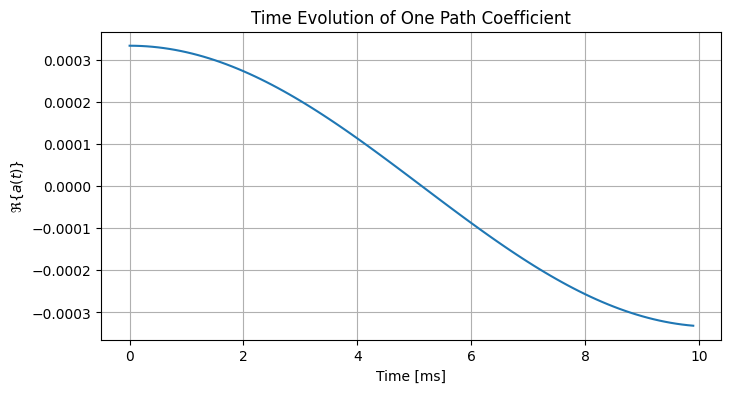

In [18]:
scene.get("tx").velocity = [10, 0, 0]

# Recompute propagation paths
paths_mob = p_solver(
    scene=scene,
    max_depth=5,
    los=True,
    specular_reflection=True,
    diffuse_reflection=True,
    refraction=True,
    synthetic_array=True,
    seed=41
)

# Compute CIR with time evolution
num_time_steps = 100
sampling_frequency = 1e4

a_mob, tau_mob = paths_mob.cir(
    sampling_frequency=sampling_frequency,
    num_time_steps=num_time_steps,
    out_type="numpy"
)

print("a_mob shape:", a_mob.shape)
print("tau_mob shape:", tau_mob.shape)

# Pick one RX/TX antenna pair and one path
rx_idx = 0
rx_ant_idx = 0
tx_idx = 0
tx_ant_idx = 0
path_idx = 0

# Extract time evolution of one path coefficient
a_path = a_mob[rx_idx, rx_ant_idx, tx_idx, tx_ant_idx, path_idx, :]

# Plot real part versus time
time_ms = np.arange(num_time_steps) / sampling_frequency * 1000

plt.figure(figsize=(8,4))
plt.plot(time_ms, a_path.real)
plt.xlabel("Time [ms]")
plt.ylabel(r"$\Re\{a(t)\}$")
plt.title("Time Evolution of One Path Coefficient")
plt.grid(True)
plt.show()

In [19]:
rm_solver = RadioMapSolver()

rm = rm_solver(scene=scene,
               max_depth=5,
               cell_size=[1,1],
               samples_per_tx=10**6)

⚠️ spectrum_to_matrix_4f: non-polarized Spectrum, using identity Jones fallback: drjit.llvm.ad.Float does not have a 'x' component.


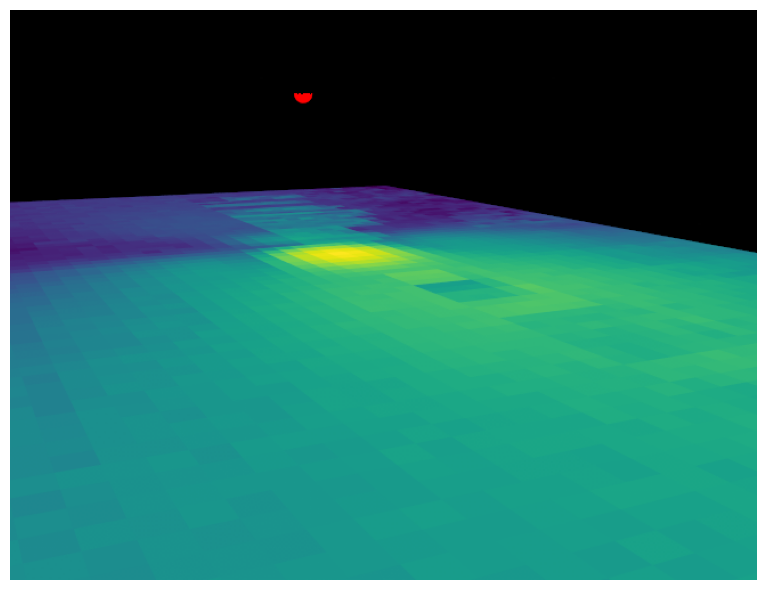

In [20]:
if no_preview:
    scene.render(camera=my_cam, radio_map=rm);
else:
    scene.preview(radio_map=rm);